# Replication Package – Digital Readiness Regimes

### This repository contains the replication materials for the paper:
### “Digital readiness regimes and upward mobility: The role of governance and skills beyond connectivity”


# Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_rand_score
import warnings
from sklearn.metrics import silhouette_score
import seaborn as sns

In [ ]:
# Function for country names matching

from rapidfuzz import process

def fuzzy_country_match(
    countries_df1,
    countries_df2,
    threshold=99,
    verbose=True
):
    """
    countries_df1 : pd.Series (np. panel_processed['country'])
    countries_df2 : pd.Series (np. robots1['country'])
    threshold     : minimalny score dopasowania
    verbose       : czy drukować raport
    
    Returns:
        mapping          : dict df2 → df1
        unmatched_df2    : list
        unmatched_df1    : list
    """

    list1 = set(countries_df1.dropna().astype(str).unique())
    list2 = set(countries_df2.dropna().astype(str).unique())

    mapping = {}
    unmatched_df2 = []
    matched_df1 = set()

    for country in list2:
        match, score, _ = process.extractOne(country, list1)

        if score >= threshold:
            mapping[country] = match
            matched_df1.add(match)
        else:
            unmatched_df2.append(country)

    unmatched_df1 = list(list1 - matched_df1)

    if verbose:
        print("Not matched from df2:")
        for c in unmatched_df2:
            print("-", c)

        print("\nNames from df1 without match in df2:")
        for c in unmatched_df1:
            print("-", c)

        print("\nMapping dict df2 → df1:")
        print(mapping)

    return mapping, unmatched_df2, unmatched_df1


In [ ]:
# Main dir

main_dir = '.../data/'

# Panel Construction
## Data Sources and matching

In [ ]:
ftri = pd.read_csv(main_dir+"US.FTRI_20260224_111200.csv") # data till 2023

itu = pd.read_csv(main_dir+"ITU_ICT (1).csv")
itu_ict = itu[itu['INDICATOR_LABEL']=='ICT Regulatory Tracker - Overall Score (ITU Regulatory Tracker)']  # data till 2022 (gap in 2021)

# https://data.worldbank.org/indicator/TX.VAL.TECH.MF.ZS
ht_exp = pd.read_csv(main_dir+"HT_exp_WDI.csv")

serv_pop = pd.read_csv(main_dir+"Services_VA_Population.csv")
serv_usd = serv_pop[serv_pop['Series Name'] == "Services, value added (current US$)"]
pop = serv_pop[serv_pop['Series Name'] == "Population, total"]

trade = pd.read_csv(main_dir+"US.TradeMatrix_20260224_114347.csv")
semi_cond = pd.read_csv(main_dir+"DataJobID-3041015_3041015_Semicondnew.csv")

In [15]:
ftri = ftri.rename(columns={"Economy_Label":'country',"Year":'year',"Overall index_Index_Value":"ftri_overall","ICT_Index_Value":"ftri_ict","Skills_Index_Value":"ftri_skills","Research and Development_Index_Value":"ftri_rd","Industry activity_Index_Value":"ftri_indact","Access to finance_Index_Value":"ftri_accfin"})

itu_ict_1 = itu_ict[["REF_AREA_LABEL","TIME_PERIOD","OBS_VALUE"]]
itu_ict_1 = itu_ict_1.rename(columns={"REF_AREA_LABEL":"country","TIME_PERIOD":"year","OBS_VALUE":"reg_ict"})

ht_exp = ht_exp.rename(columns={"Country Name":"country","Time":"year","Value":"hittech_exp"}).drop(columns=["Series Name"])
ht_exp = ht_exp.dropna(subset=["country"])

serv_usd = serv_usd.rename(columns={"Country Name":"country", "Time":"year", "Value":"serv_va_usd"}).drop(columns=["Series Name"])
pop = pop.rename(columns={"Country Name":"country", "Time":"year", "Value":"pop"}).drop(columns=["Series Name"])

trade = trade.rename(columns={"Economy_Label":'country',"Year":'year',"TOTAL ALL PRODUCTS_Exports_US_at_current_prices_in_thousands_Value":"exp_tot","TOTAL ALL PRODUCTS_Imports_US_at_current_prices_in_thousands_Value":"imp_tot"})
trade['tot_trade'] = trade["exp_tot"] + trade["imp_tot"]

semi_cond = semi_cond[["ReporterName","Year","TradeFlowName","TradeValue in 1000 USD"]]
semicond_ex = semi_cond[semi_cond["TradeFlowName"] == "Export"]
semicond_im = semi_cond[semi_cond["TradeFlowName"] == "Import"]
semicond_ex = semicond_ex.rename(columns={"ReporterName":"country","Year":"year","TradeValue in 1000 USD":"semicond_ex"}).drop(columns=["TradeFlowName"])
semicond_im = semicond_im.rename(columns={"ReporterName":"country","Year":"year","TradeValue in 1000 USD":"semicond_im"}).drop(columns=["TradeFlowName"])

In [5]:
mapping, unmatched_df2, unmatched_df1 = fuzzy_country_match(ftri['country'], itu_ict_1['country'], verbose=True)

Not matched from df2:
- Netherlands
- St. Kitts and Nevis
- Tonga
- Grenada
- Palau
- Egypt, Arab Rep.
- Hong Kong SAR, China
- Marshall Islands
- Tuvalu
- Kiribati
- Tanzania
- Slovak Republic
- Bahamas, The
- Eritrea
- Somalia
- Liechtenstein
- Nauru
- West Bank and Gaza
- Antigua and Barbuda
- Korea, Rep.
- Micronesia, Fed. Sts.
- Yemen, Rep.
- Syrian Arab Republic
- Gambia, The
- Venezuela, RB
- St. Lucia
- Congo, Dem. Rep.
- Lao PDR
- San Marino
- Congo, Rep.
- Bolivia
- Iran, Islamic Rep.
- Monaco
- Andorra
- Moldova
- Dominica
- St. Vincent and the Grenadines
- Kyrgyz Republic
- Seychelles
- Turkmenistan

Names from df1 without match in df2:
- China, Taiwan Province of
- Kyrgyzstan
- British Antarctic Territory
- Cocos (Keeling) Islands
- Yemen
- United Republic of Tanzania
- Bolivia (Plurinational State of)
- Egypt
- Republic of Moldova
- Saint Vincent and the Grenadines
- Iran (Islamic Republic of)
- Gambia
- China, Hong Kong SAR
- Sudan (...2011)
- Netherlands (Kingdom of the

In [6]:
name_map_1 = {
"Venezuela (Bolivarian Rep. of)": "Venezuela, RB",
"Lao People's Dem. Rep.": "Lao PDR",
"Bolivia (Plurinational State of)": "Bolivia",
"Iran (Islamic Republic of)": "Iran, Islamic Rep.",
"Republic of Korea": "Korea, Rep.",
"Slovakia": "Slovak Republic",
"Republic of Moldova": "Moldova",
"Kyrgyzstan": "Kyrgyz Republic",
"United Republic of Tanzania": "Tanzania",
"Dem. Rep. of the Congo": "Congo, Dem. Rep.",
"Congo": "Congo, Rep.",
"Gambia": "Gambia, The",
"Bahamas": "Bahamas, The",
"Egypt": "Egypt, Arab Rep.",
"Yemen": "Yemen, Rep.",
"Saint Lucia": "St. Lucia",
"Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
"China, Hong Kong SAR": "Hong Kong SAR, China",
"Netherlands (Kingdom of the)": "Netherlands"
}
ftri['country'] = ftri['country'].replace(name_map_1)
itu_ict_1 = itu_ict_1[itu_ict_1['country'] != 'Sudan (...2011)']

In [7]:
merge_1 = ftri.merge(itu_ict_1, on=['country','year'], how='outer')

In [12]:
mapping, unmatched_df2, unmatched_df1 = fuzzy_country_match(merge_1['country'], ht_exp['country'], verbose=True)

Not matched from df2:
- Korea, Dem. People's Rep.
- Guam
- French Polynesia
- Faroe Islands
- Greenland
- Curacao
- Somalia, Fed. Rep.
- St. Martin (French part)
- Aruba
- Turks and Caicos Islands
- Northern Mariana Islands
- American Samoa
- Sint Maarten (Dutch part)
- Isle of Man
- Channel Islands
- Kosovo
- Macao SAR, China
- New Caledonia
- Virgin Islands (U.S.)
- Puerto Rico (US)
- Gibraltar

Names from df1 without match in df2:
- Mayotte
- British Indian Ocean Territory
- China, Taiwan Province of
- British Antarctic Territory
- Cocos (Keeling) Islands
- Cook Islands
- Somalia
- Bouvet Island
- Christmas Island
- Sudan (...2011)

Mapping dict df2 → df1:
{'Netherlands': 'Netherlands', 'St. Kitts and Nevis': 'St. Kitts and Nevis', 'Mauritius': 'Mauritius', 'Togo': 'Togo', 'Pakistan': 'Pakistan', 'Tonga': 'Tonga', 'Solomon Islands': 'Solomon Islands', 'Burkina Faso': 'Burkina Faso', 'Grenada': 'Grenada', 'Liberia': 'Liberia', 'Burundi': 'Burundi', 'Palau': 'Palau', 'Bahrain': 'Bahra

In [14]:
name_map_2 = {
"Somalia": "Somalia, Fed. Rep.",
"Macao SAR, China": "Macao SAR, China",  
}
merge_1['country'] = merge_1['country'].replace(name_map_2)

countries_to_exclude = [
    'Sudan (...2011)',
    'South Sudan'
]
merge_1 = merge_1[~merge_1['country'].isin(countries_to_exclude)]

In [16]:
merge_2 = merge_1.merge(ht_exp, on=['country','year'], how='outer')

In [31]:
mapping, unmatched_df2, unmatched_df1 = fuzzy_country_match(merge_4['country'], trade['country'], verbose=True)

Not matched from df2:
- Falkland Islands (Malvinas)
- Egypt
- Republic of Moldova
- Norfolk Island
- China, Macao SAR
- China, Hong Kong SAR
- Montserrat
- Netherlands Antilles
- Congo
- Dem. People's Rep. of Korea
- Bahamas
- Saint Kitts and Nevis
- Serbia and Montenegro
- Indonesia (...2002)
- Kyrgyzstan
- Saint Pierre and Miquelon
- United Republic of Tanzania
- Bolivia (Plurinational State of)
- United States Minor Outlying Islands
- Saint Helena
- Iran (Islamic Republic of)
- Somalia
- Netherlands (Kingdom of the)
- Dem. Rep. of the Congo
- Slovakia
- Micronesia (Federated States of)
- Saint Vincent and the Grenadines
- Niue
- Republic of Korea
- State of Palestine
- Western Sahara
- Tokelau
- Yemen
- Anguilla
- Gambia
- Sudan (...2011)
- Bonaire, Sint Eustatius and Saba
- Wallis and Futuna Islands
- Saint Lucia
- Venezuela (Bolivarian Rep. of)
- Lao People's Dem. Rep.

Names from df1 without match in df2:
- Netherlands
- St. Kitts and Nevis
- Korea, Dem. People's Rep.
- West Bank

In [19]:
merge_3 = merge_2.merge(serv_usd, on=['country','year'], how='outer')

In [21]:
merge_4 = merge_3.merge(pop, on=['country','year'], how='outer')

In [33]:
countries_to_exclude_2 = ['South Sudan','Sudan (...2011)', 'Indonesia (...2002)']
trade = trade[~trade['country'].isin(countries_to_exclude)]

name_map_3 = {"Venezuela (Bolivarian Rep. of)":"Venezuela, RB","Bolivia (Plurinational State of)":"Bolivia","Iran (Islamic Republic of)":"Iran, Islamic Rep.","Republic of Korea":"Korea, Rep.","Dem. People's Rep. of Korea":"Korea, Dem. People's Rep.","United Republic of Tanzania":"Tanzania","Republic of Moldova":"Moldova","Kyrgyzstan":"Kyrgyz Republic","Slovakia":"Slovak Republic","Gambia":"Gambia, The","Bahamas":"Bahamas, The","Egypt":"Egypt, Arab Rep.","Yemen":"Yemen, Rep.","Somalia":"Somalia, Fed. Rep.","Congo":"Congo, Rep.","Dem. Rep. of the Congo":"Congo, Dem. Rep.","China, Hong Kong SAR":"Hong Kong SAR, China","China, Macao SAR":"Macao SAR, China","Saint Lucia":"St. Lucia","Saint Vincent and the Grenadines":"St. Vincent and the Grenadines","Saint Kitts and Nevis":"St. Kitts and Nevis","Lao People's Dem. Rep.":"Lao PDR","Netherlands (Kingdom of the)":"Netherlands"}
trade['country'] = trade['country'].replace(name_map_3)

In [34]:
merge_5 = merge_4.merge(trade, on=['country','year'], how='outer')

In [37]:
mapping, unmatched_df2, unmatched_df1 = fuzzy_country_match(merge_5['country'], semicond_ex['country'], verbose=True)

Not matched from df2:
- Czech Republic
- Occ.Pal.Terr
- East Timor
- Macao
- Brunei
- Vietnam
- Turks and Caicos Isl.
- Fm Sudan
- Hong Kong, China
- Turkey
- Other Asia, nes
- European Union
- Ethiopia(excludes Eritrea)
- Yemen
- Cape Verde
- Faeroe Islands
- Serbia, FR(Serbia/Montenegro)

Names from df1 without match in df2:
- Nauru
- Turkiye
- Serbia and Montenegro
- Tokelau
- Indonesia (...2002)
- Korea, Dem. People's Rep.
- Falkland Islands (Malvinas)
- British Antarctic Territory
- Vanuatu
- China, Taiwan Province of
- West Bank and Gaza
- Cocos (Keeling) Islands
- Saint Pierre and Miquelon
- Isle of Man
- San Marino
- Guam
- State of Palestine
- Micronesia (Federated States of)
- Channel Islands
- Micronesia, Fed. Sts.
- St. Martin (French part)
- Serbia
- Eritrea
- Turkmenistan
- Ethiopia
- United States Minor Outlying Islands
- Niue
- Yemen, Rep.
- Anguilla
- Norfolk Island
- Chad
- Saint Helena
- Western Sahara
- Kosovo
- Czechia
- Faroe Islands
- Netherlands Antilles
- Macao

In [38]:
name_map_4 = {"Yemen":"Yemen, Rep.","Cape Verde":"Cabo Verde","Vietnam":"Viet Nam","Hong Kong, China":"Hong Kong SAR, China","Turkey":"Turkiye","Brunei":"Brunei Darussalam","East Timor":"Timor-Leste","Macao":"Macao SAR, China","Czech Republic":"Czechia","Faeroe Islands":"Faroe Islands","Fm Sudan":"Sudan","Viet Nam":"Viet Nam","Cabo Verde":"Cabo Verde","Yemen, Rep.":"Yemen, Rep.","Brunei Darussalam":"Brunei Darussalam"}
semicond_ex['country'] = semicond_ex['country'].replace(name_map_4)
semicond_im['country'] = semicond_im['country'].replace(name_map_4)

In [39]:
merge_6 = merge_5.merge(semicond_ex, on=['country','year'], how='outer').merge(semicond_im, on=['country','year'], how='outer')

In [41]:
merge_6['semicond_trade'] = merge_6['semicond_ex'] + merge_6['semicond_im']
merge_6['semicond_share'] = merge_6['semicond_trade'] / merge_6['tot_trade']

merge_6['serv_va_pop'] = merge_6['serv_va_usd'] / merge_6['pop']

In [42]:
merge_6.to_pickle(main_dir+"df_raw.pickle")

## Missing values

In [43]:
# Most available data after 2010 and before 2024
master_y = merge_6[(merge_6['year'] > 2009) & (merge_6['year'] < 2024)]

In [44]:
cluster_vars = [
    "ftri_overall",
    "reg_ict",
    "hittech_exp",
    "semicond_share",
    "serv_va_pop"
]


In [45]:
missing_by_country = (
    master_y.groupby("country")[cluster_vars]
      .apply(lambda x: x.isna().mean())
      .reset_index()
)

In [46]:
missing_by_country["missing_avg"] = missing_by_country[cluster_vars].mean(axis=1)
missing_by_country["missing_max"] = missing_by_country[cluster_vars].max(axis=1)

In [53]:
missing_by_country.sort_values("missing_avg", ascending=False).head(81)

,country,ftri_overall,reg_ict,hittech_exp,semicond_share,serv_va_pop,missing_avg,missing_max
209,State of Palestine,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
116,"Korea, Dem. People's Rep.",1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
220,Tokelau,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
74,Ethiopia(excludes Eritrea),1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75,European Union,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...
0,Afghanistan,0.0,0.142857,0.857143,0.857143,0.000000,0.371429,0.857143
199,Solomon Islands,0.0,0.142857,0.714286,0.714286,0.000000,0.314286,0.714286
93,Guinea,0.0,0.142857,0.714286,0.714286,0.000000,0.314286,0.714286
218,Timor-Leste,0.0,0.142857,0.714286,0.714286,0.000000,0.314286,0.714286


In [ ]:
drop_all_missing = missing_by_country.loc[
    missing_by_country["missing_max"] == 1, "country"
]

In [ ]:
threshold = 0.4
bad_countries = missing_by_country.loc[
    missing_by_country["missing_avg"] > threshold, "country"
]
countries_to_drop = set(drop_all_missing).union(set(bad_countries))
# 81 countries

In [54]:
len(countries_to_drop)

81

In [55]:
master_cluster = master_y[~master_y["country"].isin(countries_to_drop)].copy()

In [56]:
master_cluster.to_pickle(main_dir+"df_cluster.pickle")
master_cluster.to_csv(main_dir+"df_cluster.csv")

In [6]:
master_cluster = pd.read_pickle(main_dir+"df_cluster.pickle")

## Imputation

In [7]:
# Only revelant cols
master_cluster_raw = master_cluster[['country', 'year', 'ftri_overall', 'ftri_ict', 'ftri_skills', 'ftri_rd','ftri_indact', 'ftri_accfin', 'reg_ict', 'hittech_exp', 'semicond_share', 'serv_va_pop'
                                     ]]

In [ ]:
df = master_cluster_raw.copy()
vars_raw = ["ftri_overall", "reg_ict", "hittech_exp", "semicond_share", "serv_va_pop"]

df = df.sort_values(["country", "year"])

# 1) Interpolacja w obrębie kraju (zachowuje index)
for v in vars_raw:
    df[v] = df.groupby("country")[v].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )

# 2) Fallback (jeśli nadal NaN)
for v in vars_raw:
    df[v] = df[v].fillna(df[v].median())


# Missing values were imputed using within-country linear interpolation over time. Remaining missing observations (for sparse country series) were replaced with the sample median to retain cross-country variation while ensuring a balanced input for clustering.

# K-means Clustering

Country–year observations were first aggregated and standardized using z-scores. Missing values were imputed using within-country linear interpolation over time with median fallback. Clusters were identified using k-means, and the optimal number of clusters was selected based on within-cluster variance and silhouette statistics.

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
df.duplicated(subset=['country','year']).sum()

0

In [12]:
# country-year level
vars_raw = ["ftri_overall", "semicond_share", "hittech_exp", "serv_va_pop", "reg_ict"]
keys = ["country", "year"]

df_cy = df.sort_values(keys)

In [ ]:
# Z-score (standarization)
scaler = StandardScaler()
X = scaler.fit_transform(df_cy[vars_raw])

for i, v in enumerate(vars_raw):
    df_cy[v + "_s"] = X[:, i]

In [14]:
# K-means for k=3..9
results = []
models = {}

for k in range(3, 10):
    km = KMeans(n_clusters=k, n_init=50, random_state=123)
    labels = km.fit_predict(X)

    inertia = km.inertia_  # odpowiednik within-SS (elbow)
    sil = silhouette_score(X, labels)

    results.append({"k": k, "inertia": inertia, "silhouette": sil})
    models[k] = km

metrics = pd.DataFrame(results)
print(metrics)

# The optimal number of clusters was determined using a combination of within-cluster variance (inertia) and silhouette statistics. While inertia decreases monotonically with the number of clusters, the silhouette score reaches its maximum at k=3, indicating the best separation between clusters. Higher values of k lead to marginal improvements in within-cluster fit but substantially lower separation quality. Therefore, a three-cluster solution is adopted as the baseline specification.

   k      inertia  silhouette
0  3  5503.126952    0.421648
1  4  4423.495201    0.316343
2  5  3619.687371    0.338452
3  6  3186.464089    0.345464
4  7  2792.515825    0.342660
5  8  2548.528004    0.342648
6  9  2345.018791    0.293410


In [15]:
k_chosen = 3

df_cy["cluster_nr_"] = models[k_chosen].predict(X) + 1  

In [16]:
cluster_map = df_cy[["country", "year", "cluster_nr_"]].copy()

In [17]:
df_kmeans = df.merge(cluster_map, on=["country", "year"], how="left")

In [18]:
df_final = master_cluster_raw.merge(cluster_map, on=["country", "year"], how="left")
# merge to raw database (not imputed)

In [ ]:
print(df_cy["cluster_nr_"].isna().sum())

print(df_cy["cluster_nr_"].value_counts())

print(df_final["cluster_nr_"].isna().mean())

0
cluster_nr_
1    1567
2     630
3      99
Name: count, dtype: int64
0.0


In [21]:
df_2023 = (
    df_final.loc[df_final["year"] == 2023, ["country", "cluster_nr_"]]
            .sort_values(["cluster_nr_", "country"])
)

print(df_2023)

          country  cluster_nr_
13    Afghanistan            1
27        Albania            1
41        Algeria            1
55         Angola            1
69      Argentina            1
...           ...          ...
1301     Malaysia            3
1343        Malta            3
1693  Philippines            3
1861    Singapore            3
2253     Viet Nam            3

[164 rows x 2 columns]


In [ ]:
cluster_col = "cluster_nr_"

vars_rows = ["ftri_overall", "semicond_share", "hittech_exp", "serv_va_pop", "reg_ict"]

df_tmp = df_final[vars_rows + [cluster_col]].copy()

for c in vars_rows:
    df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")

table_clusters = (
    df_tmp
    .groupby(cluster_col)[vars_rows]
    .mean()
    .T
)

table_clusters.columns = [f"Cluster {int(c)}" for c in table_clusters.columns]
table_clusters.index.name = "Indicators"

table_clusters = table_clusters.round(3)

table_clusters

,Cluster 1,Cluster 2,Cluster 3
Indicators,,,
ftri_overall,0.389,0.804,0.763
semicond_share,0.029,0.060,0.216
hittech_exp,5.343,15.391,46.764
serv_va_pop,3068.723,24401.216,15754.702
reg_ict,61.103,87.331,72.040


In [ ]:
# by year
cluster_col = "cluster_nr_"
year_col = "year"

vars_rows = ["ftri_overall", "semicond_share", "hittech_exp", "serv_va_pop", "reg_ict"]

df_tmp = df_final[vars_rows + [cluster_col, year_col]].copy()

for c in vars_rows:
    df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")

table_clusters_year = (
    df_tmp
    .groupby([cluster_col, year_col])[vars_rows]
    .mean()
    .reset_index()
    .sort_values([cluster_col, year_col])
)

table_clusters_year[vars_rows] = table_clusters_year[vars_rows].round(3)

table_clusters_year

,cluster_nr_,year,ftri_overall,semicond_share,hittech_exp,serv_va_pop,reg_ict
0,1,2010.0,0.408,0.028,5.375,2812.170,51.882
1,1,2011.0,0.428,0.026,5.126,3290.390,54.056
2,1,2012.0,0.423,0.026,5.199,3152.886,55.687
3,1,2013.0,0.394,0.026,5.587,3357.167,57.353
4,1,2014.0,0.335,0.027,5.425,3402.120,59.359
5,1,2015.0,0.344,0.030,5.415,3298.235,60.892
6,1,2016.0,0.433,0.032,5.608,2913.099,61.459
7,1,2017.0,0.363,0.032,6.149,3200.369,62.923
8,1,2018.0,0.408,0.029,5.389,3096.110,65.291
9,1,2019.0,0.400,0.030,5.369,3068.770,67.282


In [81]:
df_final["year"] = df_final["year"].astype(int)
df_kmeans["year"] = df_kmeans["year"].astype(int)

df_final.to_pickle(main_dir+"df_cluster_kmeans.pickle")
df_final.to_csv(main_dir+"df_cluster_kmeans.csv")
df_kmeans.to_csv(main_dir+"df_cluster_kmeans_imp.csv")
df_kmeans.to_pickle(main_dir+"df_cluster_kmeans_imp.pickle")

# Clustering statistics

In [82]:
df_kmeans

,country,year,ftri_overall,ftri_ict,ftri_skills,ftri_rd,ftri_indact,ftri_accfin,reg_ict,hittech_exp,semicond_share,serv_va_pop,cluster_nr_
0,Afghanistan,2010,0.26,0.24,0.15,0.00,0.51,0.71,47.333333,0.000000,0.009783,274.028299,1
1,Afghanistan,2011,0.26,0.23,0.16,0.00,0.56,0.62,47.333333,0.000000,0.009783,301.507964,1
2,Afghanistan,2012,0.25,0.18,0.17,0.04,0.57,0.62,51.333333,0.000000,0.009783,329.482865,1
3,Afghanistan,2013,0.19,0.19,0.17,0.06,0.33,0.63,51.333333,0.000000,0.009783,335.634962,1
4,Afghanistan,2014,0.10,0.22,0.18,0.05,0.28,0.62,63.666667,0.000000,0.009783,331.222021,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,Zimbabwe,2019,0.27,0.43,0.24,0.17,0.28,0.64,70.333333,4.949714,0.015008,758.714718,1
2292,Zimbabwe,2020,0.25,0.48,0.24,0.20,0.22,0.64,70.333333,2.383868,0.016636,720.370116,1
2293,Zimbabwe,2021,0.23,0.44,0.25,0.19,0.21,0.66,70.333333,1.053740,0.016168,984.755096,1
2294,Zimbabwe,2022,0.24,0.39,0.25,0.21,0.22,0.68,70.333333,1.476931,0.021712,726.949043,1


In [30]:
# ARI
df = df_kmeans.copy()
warnings.filterwarnings("ignore")
np.random.seed(42)


# Define years and features
years = list(range(2010, 2024))
features = ['ftri_overall', 'reg_ict', 'hittech_exp', 'semicond_share', 'serv_va_pop']

# Collect results
results = []

for year in years:
    df_year = df[df['year'] == year].copy()
    
    # Drop rows with missing values in features or cluster assignments
    df_year = df_year.dropna(subset=features + ['cluster_nr_'])
    
    if df_year.empty:
        continue

    # Scale data
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df_year[features])
    true_labels = df_year['cluster_nr_'].values

    n_boot = 30
    ari_scores = []

    for _ in range(n_boot):
        sample_idx = np.random.choice(len(X), size=int(len(X) * 0.8), replace=True)
        X_sample = X[sample_idx]
        true_sample = true_labels[sample_idx]

        kmeans_sample = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_sample)
        predicted_labels = kmeans_sample.labels_

        ari = adjusted_rand_score(true_sample, predicted_labels)
        ari_scores.append(ari)

    avg_ari = np.mean(ari_scores)
    results.append({'year': year, 'ARI_vs_original': round(avg_ari, 3)})

# Save results to CSV
ari_df = pd.DataFrame(results)

ari_df


,year,ARI_vs_original
0,2010,0.636
1,2011,0.580
2,2012,0.652
3,2013,0.554
4,2014,0.611
5,2015,0.538
6,2016,0.617
7,2017,0.566
8,2018,0.653
9,2019,0.594


In [84]:
# sensitivity_ARI

features = ['ftri_overall', 'reg_ict', 'hittech_exp', 'semicond_share', 'serv_va_pop']
sensitivity_results = []

for year in range(2010, 2024):
    df_year = df[df['year'] == year].copy()
    
    df_year = df_year.dropna(subset=features)
    
    if df_year.empty:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])

    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)

    X_noise = X + np.random.normal(0, 0.01, size=X.shape)
    kmeans_noise = KMeans(n_clusters=3, random_state=0).fit(X_noise)

    ari = adjusted_rand_score(kmeans.labels_, kmeans_noise.labels_)
    sensitivity_results.append({'year': year, 'sensitivity_ARI': round(ari, 3)})

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df)

    year  sensitivity_ARI
0   2010            0.458
1   2011            0.608
2   2012            0.357
3   2013            0.446
4   2014            0.408
5   2015            0.338
6   2016            0.475
7   2017            0.389
8   2018            0.449
9   2019            0.979
10  2020            0.612
11  2021            0.501
12  2022            1.000
13  2023            0.636


In [ ]:
# silhouette_score

silhouette_results = []

for year in range(2010, 2024):
    df_year = df[df['year'] == year].copy()
    
    # Dropping countries with missing data
    df_year = df_year.dropna(subset=features)
    
    if df_year.empty:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)

    # Silhouette score
    sil_score = silhouette_score(X, kmeans.labels_)
    silhouette_results.append({'year': year, 'silhouette_score': round(sil_score, 3)})

silhouette_df = pd.DataFrame(silhouette_results)
print(silhouette_df)

    year  silhouette_score
0   2010             0.340
1   2011             0.312
2   2012             0.285
3   2013             0.419
4   2014             0.431
5   2015             0.417
6   2016             0.346
7   2017             0.395
8   2018             0.428
9   2019             0.320
10  2020             0.407
11  2021             0.426
12  2022             0.333
13  2023             0.338


In [ ]:
grouped = (
    df.groupby(["year", "cluster_nr_"])["country"]
    .apply(lambda x: ", ".join(sorted(set(x))))
    .reset_index()
)

# pivot 
cluster_table = grouped.pivot(index="cluster_nr_", columns="year", values="country")

# sort
cluster_table = cluster_table.sort_index()

cluster_table.head()


year,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
cluster_nr_,,,,,,,,,,,,,,
1,"Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti...","Afghanistan, Albania, Algeria, Angola, Argenti..."
2,"Australia, Austria, Belgium, Brazil, Bulgaria,...","Australia, Austria, Belgium, Brazil, Bulgaria,...","Australia, Austria, Barbados, Belgium, Brazil,...","Australia, Austria, Belgium, Brazil, Bulgaria,...","Australia, Austria, Belgium, Brazil, Bulgaria,...","Australia, Austria, Belgium, Brazil, Bulgaria,...","Australia, Austria, Bahrain, Barbados, Belgium...","Australia, Austria, Bahamas, The, Belgium, Bra...","Australia, Austria, Bahamas, The, Barbados, Be...","Australia, Austria, Bahamas, The, Bahrain, Bar...","Australia, Austria, Bahrain, Barbados, Belgium...","Australia, Austria, Bahamas, The, Barbados, Be...","Australia, Austria, Bahamas, The, Barbados, Be...","Australia, Austria, Bahamas, The, Barbados, Be..."
3,"China, Costa Rica, Hong Kong SAR, China, Malay...","China, Costa Rica, Malaysia, Malta, Philippine...","China, Costa Rica, Malaysia, Malta, Philippine...","China, Costa Rica, Malaysia, Malta, Philippine...","China, Costa Rica, Malaysia, Malta, Philippine...","China, Korea, Rep., Malaysia, Malta, Philippin...","China, Korea, Rep., Malaysia, Philippines, Sao...","China, Hong Kong SAR, China, Korea, Rep., Mala...","China, Hong Kong SAR, China, Korea, Rep., Mala...","Central African Republic, China, Hong Kong SAR...","China, Hong Kong SAR, China, Korea, Rep., Mala...","China, Cuba, Hong Kong SAR, China, Korea, Rep....","China, Hong Kong SAR, China, Korea, Rep., Mala...","China, Hong Kong SAR, China, Korea, Rep., Mala..."


In [ ]:
rok = 2023

table_2023 = (
    cluster_table[[rok]]                 
    .reset_index()                       
    .rename(columns={"cluster_nr_": "cluster", rok: "country_name"})
)
print(table_2023.to_csv(sep="\t", index=False))
table_2023

cluster	country_name
1	Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Belarus, Belize, Benin, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brunei Darussalam, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Central African Republic, Colombia, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Cuba, Djibouti, Dominican Republic, Ecuador, Egypt, Arab Rep., El Salvador, Eswatini, Fiji, Gabon, Gambia, The, Georgia, Ghana, Guatemala, Guinea, Guinea-Bissau, Guyana, Honduras, Indonesia, Iran, Islamic Rep., Jamaica, Jordan, Kazakhstan, Kenya, Kuwait, Kyrgyz Republic, Lao PDR, Lebanon, Lesotho, Liberia, Libya, Madagascar, Malawi, Maldives, Mali, Mauritania, Mauritius, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Namibia, Nepal, Nicaragua, Niger, Nigeria, Oman, Pakistan, Panama, Papua New Guinea, Paraguay, Peru, Russian Federation, Rwanda, Samoa, Sao Tome and Principe, Senegal, Sierra Leone, Solomon Islands, South Afric

year,cluster,country_name
0,1,"Afghanistan, Albania, Algeria, Angola, Argenti..."
1,2,"Australia, Austria, Bahamas, The, Barbados, Be..."
2,3,"China, Hong Kong SAR, China, Korea, Rep., Mala..."


# Alternative clustering methods

In [37]:
vars_raw

['ftri_overall', 'semicond_share', 'hittech_exp', 'serv_va_pop', 'reg_ict']

In [38]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

results = []

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy()
    df_year = df_year.dropna(subset=features)

    if len(df_year) < 10:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])

    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
    labels = kmeans.labels_

    # --- metrics ---
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    inertia = kmeans.inertia_

    # --- bootstrap stability ---
    true_labels = labels.copy()
    ari_scores = []

    for _ in range(30):
        idx = np.random.choice(len(X), size=int(len(X)*0.8), replace=True)
        X_sample = X[idx]
        labels_sample = true_labels[idx]

        km_s = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_sample)
        ari = adjusted_rand_score(labels_sample, km_s.labels_)
        ari_scores.append(ari)

    stability = np.mean(ari_scores)

    # --- noise sensitivity ---
    X_noise = X + np.random.normal(0, 0.01, size=X.shape)
    km_noise = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_noise)
    noise_ari = adjusted_rand_score(labels, km_noise.labels_)

    results.append({
        "year": year,
        "method": "kmeans",
        "k": 3,
        "n_obs": len(df_year),
        "silhouette": round(sil, 3),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 3),
        "inertia": round(inertia, 1),
        "stability_ARI": round(stability, 3),
        "noise_ARI": round(noise_ari, 3)
    })

kmeans_results = pd.DataFrame(results)
kmeans_results

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI
0,2010,kmeans,3,164,0.340,94.2,1.093,14.8,0.691,1.000
1,2011,kmeans,3,164,0.312,96.2,1.139,14.1,0.640,0.445
2,2012,kmeans,3,164,0.285,97.2,1.182,14.7,0.534,0.712
3,2013,kmeans,3,164,0.419,94.7,1.027,15.2,0.664,1.000
4,2014,kmeans,3,164,0.431,96.2,1.071,15.0,0.725,0.977
5,2015,kmeans,3,164,0.417,90.1,1.127,15.4,0.553,0.977
6,2016,kmeans,3,164,0.346,82.8,1.165,14.1,0.638,0.982
7,2017,kmeans,3,164,0.395,91.3,0.966,14.6,0.600,0.931
8,2018,kmeans,3,164,0.428,96.0,0.855,13.2,0.570,1.000
9,2019,kmeans,3,164,0.320,96.2,1.111,11.6,0.686,0.931


Clustering quality was evaluated using silhouette, Calinski–Harabasz, and Davies–Bouldin indices. Cluster stability was assessed via bootstrap resampling (adjusted Rand index), and sensitivity to noise was evaluated by perturbing the data with small Gaussian noise.

In [ ]:
## 1) Hierarchical clustering (agglomerative)

from sklearn.cluster import AgglomerativeClustering

results_hc = []

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy()
    df_year = df_year.dropna(subset=features)

    if len(df_year) < 10:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])

    # HIERARCHICAL WARD
    hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels = hc.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    # pseudo-inertia (bo hierarchical nie ma inertia)
    inertia = np.sum([
        np.sum((X[labels == c] - X[labels == c].mean(axis=0))**2)
        for c in np.unique(labels)
    ])

    # --- bootstrap stability ---
    true_labels = labels.copy()
    ari_scores = []

    for _ in range(30):
        idx = np.random.choice(len(X), size=int(len(X)*0.8), replace=True)
        X_sample = X[idx]
        labels_sample = true_labels[idx]

        hc_s = AgglomerativeClustering(n_clusters=3, linkage="ward")
        labels_s = hc_s.fit_predict(X_sample)

        ari = adjusted_rand_score(labels_sample, labels_s)
        ari_scores.append(ari)

    stability = np.mean(ari_scores)

    # --- noise sensitivity ---
    X_noise = X + np.random.normal(0, 0.01, size=X.shape)
    hc_noise = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels_noise = hc_noise.fit_predict(X_noise)

    noise_ari = adjusted_rand_score(labels, labels_noise)

    results_hc.append({
        "year": year,
        "method": "hierarchical_ward",
        "k": 3,
        "n_obs": len(df_year),
        "silhouette": round(sil, 3),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 3),
        "inertia": round(inertia, 1),
        "stability_ARI": round(stability, 3),
        "noise_ARI": round(noise_ari, 3)
    })

    # HIERARCHICAL AVERAGE
    hc = AgglomerativeClustering(n_clusters=3, linkage="average", metric="euclidean")
    labels = hc.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    inertia = np.sum([
        np.sum((X[labels == c] - X[labels == c].mean(axis=0))**2)
        for c in np.unique(labels)
    ])

    # bootstrap
    true_labels = labels.copy()
    ari_scores = []

    for _ in range(30):
        idx = np.random.choice(len(X), size=int(len(X)*0.8), replace=True)
        X_sample = X[idx]
        labels_sample = true_labels[idx]

        hc_s = AgglomerativeClustering(n_clusters=3, linkage="average", metric="euclidean")
        labels_s = hc_s.fit_predict(X_sample)

        ari = adjusted_rand_score(labels_sample, labels_s)
        ari_scores.append(ari)

    stability = np.mean(ari_scores)

    # noise
    X_noise = X + np.random.normal(0, 0.01, size=X.shape)
    hc_noise = AgglomerativeClustering(n_clusters=3, linkage="average", metric="euclidean")
    labels_noise = hc_noise.fit_predict(X_noise)

    noise_ari = adjusted_rand_score(labels, labels_noise)

    results_hc.append({
        "year": year,
        "method": "hierarchical_average",
        "k": 3,
        "n_obs": len(df_year),
        "silhouette": round(sil, 3),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 3),
        "inertia": round(inertia, 1),
        "stability_ARI": round(stability, 3),
        "noise_ARI": round(noise_ari, 3)
    })

hc_results = pd.DataFrame(results_hc)
hc_results

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI
0,2010,hierarchical_ward,3,164,0.259,88.3,1.182,15.3,0.537,0.948
1,2010,hierarchical_average,3,164,0.460,17.0,0.524,26.5,0.713,1.000
2,2011,hierarchical_ward,3,164,0.365,87.6,1.125,14.9,0.587,0.679
3,2011,hierarchical_average,3,164,0.461,18.2,0.658,25.3,0.892,1.000
4,2012,hierarchical_ward,3,164,0.270,89.7,1.144,15.3,0.496,0.487
5,2012,hierarchical_average,3,164,0.447,16.9,0.689,26.8,0.682,0.915
6,2013,hierarchical_ward,3,164,0.433,90.9,1.053,15.5,0.592,0.659
7,2013,hierarchical_average,3,164,0.450,18.1,0.610,27.0,0.604,0.915
8,2014,hierarchical_ward,3,164,0.429,89.3,1.141,15.6,0.445,0.336
9,2014,hierarchical_average,3,164,0.441,6.9,0.363,30.3,0.558,0.380


In [40]:
all_results = pd.concat([kmeans_results, hc_results], ignore_index=True)
all_results.sort_values(["year", "method"])

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI
15,2010,hierarchical_average,3,164,0.460,17.0,0.524,26.5,0.713,1.000
14,2010,hierarchical_ward,3,164,0.259,88.3,1.182,15.3,0.537,0.948
0,2010,kmeans,3,164,0.340,94.2,1.093,14.8,0.691,1.000
17,2011,hierarchical_average,3,164,0.461,18.2,0.658,25.3,0.892,1.000
16,2011,hierarchical_ward,3,164,0.365,87.6,1.125,14.9,0.587,0.679
1,2011,kmeans,3,164,0.312,96.2,1.139,14.1,0.640,0.445
19,2012,hierarchical_average,3,164,0.447,16.9,0.689,26.8,0.682,0.915
18,2012,hierarchical_ward,3,164,0.270,89.7,1.144,15.3,0.496,0.487
2,2012,kmeans,3,164,0.285,97.2,1.182,14.7,0.534,0.712
21,2013,hierarchical_average,3,164,0.450,18.1,0.610,27.0,0.604,0.915


In [ ]:
# 2) K-medoids 
from sklearn_extra.cluster import KMedoids

results_kmed = []

k = 3
n_boot = 30
noise_sd = 0.01

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy()
    df_year = df_year.dropna(subset=features)

    if len(df_year) < 10:
        continue
    if len(df_year) <= k:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])

    # ============ main fit ============
    kmed = KMedoids(
        n_clusters=k,
        metric="euclidean",
        init="k-medoids++",
        random_state=0
    ).fit(X)

    labels = kmed.labels_

    # quality metrics
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    # pseudo-inertia: within-cluster SSE 
    inertia = np.sum([
        np.sum((X[labels == c] - X[labels == c].mean(axis=0))**2)
        for c in np.unique(labels)
    ])

    # ============ bootstrap stability ============
    true_labels = labels.copy()
    ari_scores = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X), size=int(len(X) * 0.8), replace=True)
        X_sample = X[idx]
        labels_sample = true_labels[idx]

        kmed_s = KMedoids(
            n_clusters=k,
            metric="euclidean",
            init="k-medoids++",
            random_state=0
        ).fit(X_sample)

        ari_scores.append(adjusted_rand_score(labels_sample, kmed_s.labels_))

    stability = float(np.mean(ari_scores))

    # ============ noise sensitivity ============
    X_noise = X + np.random.normal(0, noise_sd, size=X.shape)

    kmed_noise = KMedoids(
        n_clusters=k,
        metric="euclidean",
        init="k-medoids++",
        random_state=0
    ).fit(X_noise)

    noise_ari = adjusted_rand_score(labels, kmed_noise.labels_)

    results_kmed.append({
        "year": year,
        "method": "kmedoids",
        "k": k,
        "n_obs": len(df_year),
        "silhouette": round(sil, 3),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 3),
        "inertia": round(inertia, 1),
        "stability_ARI": round(stability, 3),
        "noise_ARI": round(noise_ari, 3)
    })

kmed_results = pd.DataFrame(results_kmed).sort_values("year")
kmed_results

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI
0,2010,kmedoids,3,164,0.299,87.7,1.185,15.4,0.554,0.984
1,2011,kmedoids,3,164,0.273,87.1,1.164,14.9,0.503,0.713
2,2012,kmedoids,3,164,0.445,91.2,0.867,15.2,0.445,0.976
3,2013,kmedoids,3,164,0.433,88.7,0.941,15.7,0.508,0.982
4,2014,kmedoids,3,164,0.424,91.1,1.030,15.4,0.674,0.977
5,2015,kmedoids,3,164,0.402,82.6,1.134,16.1,0.543,0.834
6,2016,kmedoids,3,164,0.384,76.3,1.186,14.7,0.503,0.691
7,2017,kmedoids,3,164,0.421,91.0,0.928,14.7,0.545,0.624
8,2018,kmedoids,3,164,0.359,80.9,0.928,14.4,0.578,0.853
9,2019,kmedoids,3,164,0.408,85.0,0.908,12.4,0.584,0.521


In [42]:
all_results = pd.concat([kmeans_results, hc_results, kmed_results], ignore_index=True)
all_results.sort_values(["year", "method"])

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI
15,2010,hierarchical_average,3,164,0.460,17.0,0.524,26.5,0.713,1.000
14,2010,hierarchical_ward,3,164,0.259,88.3,1.182,15.3,0.537,0.948
0,2010,kmeans,3,164,0.340,94.2,1.093,14.8,0.691,1.000
42,2010,kmedoids,3,164,0.299,87.7,1.185,15.4,0.554,0.984
17,2011,hierarchical_average,3,164,0.461,18.2,0.658,25.3,0.892,1.000
16,2011,hierarchical_ward,3,164,0.365,87.6,1.125,14.9,0.587,0.679
1,2011,kmeans,3,164,0.312,96.2,1.139,14.1,0.640,0.445
43,2011,kmedoids,3,164,0.273,87.1,1.164,14.9,0.503,0.713
19,2012,hierarchical_average,3,164,0.447,16.9,0.689,26.8,0.682,0.915
18,2012,hierarchical_ward,3,164,0.270,89.7,1.144,15.3,0.496,0.487


In [ ]:
# 3) Model-based clustering: Gaussian Mixture Models (GMM)
from sklearn.mixture import GaussianMixture

results_gmm = []

k = 3
n_boot = 30
noise_sd = 0.01

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy()
    df_year = df_year.dropna(subset=features)

    if len(df_year) < 10:
        continue
    if len(df_year) <= k:
        continue

    X = StandardScaler().fit_transform(df_year[features])

    # ============ main fit ============
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        n_init=10,
        random_state=0
    ).fit(X)

    labels = gmm.predict(X)

    # quality metrics (geometry)
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    # model-based metrics
    loglik = gmm.score(X)            # average log-likelihood per obs
    bic = gmm.bic(X)
    aic = gmm.aic(X)

    # ============ bootstrap stability ============
    true_labels = labels.copy()
    ari_scores = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X), size=int(len(X) * 0.8), replace=True)
        X_sample = X[idx]
        labels_sample = true_labels[idx]

        gmm_s = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=10,
            random_state=0
        ).fit(X_sample)

        labels_s = gmm_s.predict(X_sample)
        ari_scores.append(adjusted_rand_score(labels_sample, labels_s))

    stability = float(np.mean(ari_scores))

    # ============ noise sensitivity ============
    X_noise = X + np.random.normal(0, noise_sd, size=X.shape)

    gmm_noise = GaussianMixture(
        n_components=k,
        covariance_type="full",
        n_init=10,
        random_state=0
    ).fit(X_noise)

    labels_noise = gmm_noise.predict(X_noise)
    noise_ari = adjusted_rand_score(labels, labels_noise)

    results_gmm.append({
        "year": year,
        "method": "gmm",
        "k": k,
        "n_obs": len(df_year),
        "silhouette": round(sil, 3),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 3),
        "loglik_avg": round(loglik, 3),
        "bic": round(bic, 1),
        "aic": round(aic, 1),
        "stability_ARI": round(stability, 3),
        "noise_ARI": round(noise_ari, 3)
    })

gmm_results = pd.DataFrame(results_gmm).sort_values("year")
gmm_results

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,loglik_avg,bic,aic,stability_ARI,noise_ARI
0,2010,gmm,3,164,0.249,58.8,1.266,-3.798,1561.9,1369.7,0.422,1.000
1,2011,gmm,3,164,0.334,74.9,1.003,-3.769,1552.4,1360.2,0.543,1.000
2,2012,gmm,3,164,0.193,53.8,1.977,-3.752,1546.8,1354.6,0.525,1.000
3,2013,gmm,3,164,0.310,58.1,1.476,-3.686,1525.3,1333.1,0.627,1.000
4,2014,gmm,3,164,0.277,52.3,1.654,-3.759,1549.3,1357.1,0.595,1.000
5,2015,gmm,3,164,0.168,42.0,1.981,-3.943,1609.3,1417.1,0.440,0.513
6,2016,gmm,3,164,0.270,52.5,1.474,-3.931,1605.5,1413.4,0.643,0.878
7,2017,gmm,3,164,0.261,62.9,1.400,-3.943,1609.6,1417.4,0.664,0.978
8,2018,gmm,3,164,0.278,53.0,1.188,-3.674,1521.2,1329.0,0.600,1.000
9,2019,gmm,3,164,0.321,67.1,1.306,-3.638,1509.5,1317.4,0.754,0.954


In [44]:
all_results = pd.concat([kmeans_results, hc_results, kmed_results, gmm_results], ignore_index=True)
all_results.sort_values(["year", "method"])

,year,method,k,n_obs,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI,loglik_avg,bic,aic
56,2010,gmm,3,164,0.249,58.8,1.266,NaN,0.422,1.000,-3.798,1561.9,1369.7
15,2010,hierarchical_average,3,164,0.460,17.0,0.524,26.5,0.713,1.000,NaN,NaN,NaN
14,2010,hierarchical_ward,3,164,0.259,88.3,1.182,15.3,0.537,0.948,NaN,NaN,NaN
0,2010,kmeans,3,164,0.340,94.2,1.093,14.8,0.691,1.000,NaN,NaN,NaN
42,2010,kmedoids,3,164,0.299,87.7,1.185,15.4,0.554,0.984,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2023,gmm,3,164,0.285,72.7,1.211,NaN,0.710,0.965,-3.607,1499.4,1307.2
41,2023,hierarchical_average,3,164,0.500,21.8,0.600,21.5,0.653,1.000,NaN,NaN,NaN
40,2023,hierarchical_ward,3,164,0.413,98.3,0.876,12.3,0.610,0.660,NaN,NaN,NaN
13,2023,kmeans,3,164,0.338,105.7,1.111,11.8,0.620,0.924,NaN,NaN,NaN


In [45]:
all_results.to_excel("all_results.xlsx", index=False)

In [54]:
avg_results = (
    all_results
    .groupby("method")[[
        "silhouette",
        "calinski_harabasz",
        "davies_bouldin",
        "inertia",
        "stability_ARI",
        "noise_ARI",
        "loglik_avg",
        "bic",
        "aic"
    ]]
    .mean()
    .reset_index()
)

avg_results

,method,silhouette,calinski_harabasz,davies_bouldin,inertia,stability_ARI,noise_ARI,loglik_avg,bic,aic
0,gmm,0.269214,58.771429,1.407429,NaN,0.602786,0.944357,-3.696286,1528.578571,1336.4
1,hierarchical_average,0.472714,17.278571,0.573286,24.607143,0.633000,0.901929,NaN,NaN,NaN
2,hierarchical_ward,0.349714,88.671429,1.069929,14.200000,0.543357,0.666143,NaN,NaN,NaN
3,kmeans,0.371214,96.442857,1.052214,13.592857,0.639071,0.916643,NaN,NaN,NaN
4,kmedoids,0.374786,89.414286,1.038714,14.157143,0.564286,0.750786,NaN,NaN,NaN


# Sensitivity analysis with alternative numbers of clusters

In [ ]:
# GMM 

bic_rows = []
ks = range(2, 7)   

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy().dropna(subset=features)

    if len(df_year) < 10:
        continue

    X = StandardScaler().fit_transform(df_year[features])

    for k in ks:
        gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=10, random_state=0)
        gmm.fit(X)

        bic_rows.append({
            "year": year,
            "k": k,
            "bic": gmm.bic(X),
            "aic": gmm.aic(X)
        })

bic_table = pd.DataFrame(bic_rows)

In [47]:
# choosing the best k

best_k_gmm = bic_table.loc[bic_table.groupby("year")["bic"].idxmin()]
best_k_gmm = best_k_gmm.sort_values("year")
best_k_gmm

,year,k,bic,aic
4,2010,6,1533.878679,1146.395376
9,2011,6,1517.189306,1129.706002
14,2012,6,1536.739021,1149.255718
16,2013,3,1525.326250,1333.134532
21,2014,3,1549.265466,1357.073747
27,2015,4,1559.906904,1302.617990
31,2016,3,1605.542609,1413.350891
37,2017,4,1524.754622,1267.465708
42,2018,4,1477.942477,1220.653563
47,2019,4,1436.052671,1178.763758


In [48]:
best_k_gmm["k"].value_counts().sort_index()

k
3    3
4    5
5    1
6    5
Name: count, dtype: int64

In [49]:
# hierarchical (Ward)

rows = []

for year in range(2010, 2024):
    df_year = df[df["year"] == year].copy().dropna(subset=features)

    if len(df_year) < 10:
        continue

    X = MinMaxScaler().fit_transform(df_year[features])

    for k in range(2, 7):
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X)

        if len(np.unique(labels)) < 2:
            continue

        sil = silhouette_score(X, labels)

        rows.append({
            "year": year,
            "method": "hierarchical_ward",
            "k": k,
            "silhouette": sil
        })

hc_sil = pd.DataFrame(rows)

In [119]:
best_k_hc = hc_sil.loc[hc_sil.groupby("year")["silhouette"].idxmax()]
best_k_hc["k"].value_counts().sort_index()

k
2    10
3     3
6     1
Name: count, dtype: int64

In [ ]:
YEARS = range(2010, 2024)
K_RANGE = range(2, 7)   
RANDOM_STATE = 0
N_INIT = 20

def metrics_kmeans_year(df, year, features, k):
    d = df.loc[df["year"] == year].dropna(subset=features).copy()
    if len(d) <= k: return None
    X = MinMaxScaler().fit_transform(d[features])
    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE).fit(X)
    labels = km.labels_
    if len(np.unique(labels)) < 2: return None
    return {
        "sil": silhouette_score(X, labels),
        "ch": calinski_harabasz_score(X, labels),
        "db": davies_bouldin_score(X, labels),
        "inertia": km.inertia_
    }

def metrics_kmedoids_year(df, year, features, k):
    d = df.loc[df["year"] == year].dropna(subset=features).copy()
    if len(d) <= k: return None
    X = MinMaxScaler().fit_transform(d[features])
    kmed = KMedoids(n_clusters=k, init="k-medoids++", metric="euclidean", random_state=RANDOM_STATE).fit(X)
    labels = kmed.labels_
    if len(np.unique(labels)) < 2: return None
    inertia = np.sum([np.sum((X[labels==c] - X[labels==c].mean(axis=0))**2) for c in np.unique(labels)])
    return {
        "sil": silhouette_score(X, labels),
        "ch": calinski_harabasz_score(X, labels),
        "db": davies_bouldin_score(X, labels),
        "inertia": inertia
    }

def metrics_hier_ward_year(df, year, features, k):
    d = df.loc[df["year"] == year].dropna(subset=features).copy()
    if len(d) <= k: return None
    X = MinMaxScaler().fit_transform(d[features])
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    labels = hc.labels_
    if len(np.unique(labels)) < 2: return None
    inertia = np.sum([np.sum((X[labels==c] - X[labels==c].mean(axis=0))**2) for c in np.unique(labels)])
    return {
        "sil": silhouette_score(X, labels),
        "ch": calinski_harabasz_score(X, labels),
        "db": davies_bouldin_score(X, labels),
        "inertia": inertia
    }

def metrics_gmm_year(df, year, features, k):
    d = df.loc[df["year"] == year].dropna(subset=features).copy()
    if len(d) <= k: return None
    X = StandardScaler().fit_transform(d[features])
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=10,
                          random_state=RANDOM_STATE, reg_covar=1e-6).fit(X)
    labels = gmm.predict(X)
    if len(np.unique(labels)) < 2: return None
    return {
        "sil": silhouette_score(X, labels),
        "ch": calinski_harabasz_score(X, labels),
        "db": davies_bouldin_score(X, labels),
        "bic": gmm.bic(X),
        "aic": gmm.aic(X),
        "loglik_avg": gmm.score(X)  
    }

In [51]:
rows = []

for year in YEARS:
    for k in K_RANGE:
        # k-means
        m = metrics_kmeans_year(df, year, features, k)
        if m:
            rows.append({"year": year, "method": "kmeans", "k": k, **m})

        # k-medoids
        m = metrics_kmedoids_year(df, year, features, k)
        if m:
            rows.append({"year": year, "method": "kmedoids", "k": k, **m})

        # hierarchical Ward
        m = metrics_hier_ward_year(df, year, features, k)
        if m:
            rows.append({"year": year, "method": "hier_ward", "k": k, **m})

        # GMM
        m = metrics_gmm_year(df, year, features, k)
        if m:
            rows.append({"year": year, "method": "gmm", "k": k, **m})

metrics_long = pd.DataFrame(rows)
metrics_long.head()

,year,method,k,sil,ch,db,inertia,bic,aic,loglik_avg
0,2010,kmeans,2,0.429486,113.346217,1.015447,18.902082,NaN,NaN,NaN
1,2010,kmedoids,2,0.425680,113.083180,1.020165,18.920157,NaN,NaN,NaN
2,2010,hier_ward,2,0.435247,113.051115,1.008747,18.922362,NaN,NaN,NaN
3,2010,gmm,2,0.317526,74.178553,1.309564,NaN,1611.921153,1484.82663,-4.27691
4,2010,kmeans,3,0.339945,94.188431,1.092544,14.804900,NaN,NaN,NaN


In [ ]:

agg_geo = (
    metrics_long[metrics_long["method"] != "gmm"]
    .groupby(["method", "k"])
    .agg(
        years_used=("year", "nunique"),
        sil_mean=("sil", "mean"),
        sil_median=("sil", "median"),
        ch_mean=("ch", "mean"),
        db_mean=("db", "mean"),
        inertia_mean=("inertia", "mean")
    )
    .reset_index()
)


agg_gmm = (
    metrics_long[metrics_long["method"] == "gmm"]
    .groupby(["method", "k"])
    .agg(
        years_used=("year", "nunique"),
        sil_mean=("sil", "mean"),
        ch_mean=("ch", "mean"),
        db_mean=("db", "mean"),
        bic_sum=("bic", "sum"),
        aic_sum=("aic", "sum"),
        bic_mean=("bic", "mean"),
        aic_mean=("aic", "mean")
    )
    .reset_index()
)

agg_geo, agg_gmm

(       method  k  years_used  sil_mean  sil_median     ch_mean   db_mean  \
 0   hier_ward  2          14  0.404672    0.417881  107.500330  1.026851   
 1   hier_ward  3          14  0.349618    0.350365   88.658043  1.070120   
 2   hier_ward  4          14  0.309908    0.299273   85.656787  1.035239   
 3   hier_ward  5          14  0.316605    0.303578   86.173899  0.997752   
 4   hier_ward  6          14  0.301891    0.299602   85.159459  0.993543   
 5      kmeans  2          14  0.428547    0.435323  120.221431  0.981683   
 6      kmeans  3          14  0.377077    0.377408   96.517750  1.043032   
 7      kmeans  4          14  0.350289    0.348964   95.609248  0.993173   
 8      kmeans  5          14  0.345014    0.340363   97.194742  0.958610   
 9      kmeans  6          14  0.336366    0.338718   94.975955  0.937666   
 10   kmedoids  2          14  0.405910    0.406345  109.821198  1.009009   
 11   kmedoids  3          14  0.374747    0.398579   89.415984  1.038619   

In [ ]:
def choose_k_geo(df_method):
    
    dfm = df_method.copy()
    dfm = dfm.sort_values(["sil_mean", "ch_mean", "db_mean"], ascending=[False, False, True])
    return int(dfm.iloc[0]["k"])

best_k = {}

for m in ["kmeans", "kmedoids", "hier_ward"]:
    best_k[m] = choose_k_geo(agg_geo[agg_geo["method"] == m])


best_k["gmm_bic"] = int(agg_gmm.sort_values("bic_sum").iloc[0]["k"])
best_k["gmm_aic"] = int(agg_gmm.sort_values("aic_sum").iloc[0]["k"])

best_k

{'kmeans': 2, 'kmedoids': 2, 'hier_ward': 2, 'gmm_bic': 4, 'gmm_aic': 6}

In [ ]:

appendix_table = (
    agg_geo.rename(columns={"method":"method"})
    .merge(
        agg_gmm[["k","bic_sum","aic_sum","bic_mean","aic_mean"]],
        on="k", how="left"
    )
    .sort_values(["method","k"])
)

appendix_table

,method,k,years_used,sil_mean,sil_median,ch_mean,db_mean,inertia_mean,bic_sum,aic_sum,bic_mean,aic_mean
0,hier_ward,2,14,0.404672,0.417881,107.500330,1.026851,17.965326,22561.500276,20782.176946,1611.535734,1484.441210
1,hier_ward,3,14,0.349618,0.350365,88.658043,1.070120,14.207063,21400.263520,18709.579460,1528.590251,1336.398533
2,hier_ward,4,14,0.309908,0.299273,85.656787,1.035239,11.470316,21044.642272,17442.597482,1503.188734,1245.899820
3,hier_ward,5,14,0.316605,0.303578,86.173899,0.997752,9.446785,21144.354704,16630.949185,1510.311050,1187.924942
4,hier_ward,6,14,0.301891,0.299602,85.159459,0.993543,8.099759,21251.344576,15826.578328,1517.953184,1130.469881
5,kmeans,2,14,0.428547,0.435323,120.221431,0.981683,17.127538,22561.500276,20782.176946,1611.535734,1484.441210
6,kmeans,3,14,0.377077,0.377408,96.517750,1.043032,13.581233,21400.263520,18709.579460,1528.590251,1336.398533
7,kmeans,4,14,0.350289,0.348964,95.609248,0.993173,10.694199,21044.642272,17442.597482,1503.188734,1245.899820
8,kmeans,5,14,0.345014,0.340363,97.194742,0.958610,8.697388,21144.354704,16630.949185,1510.311050,1187.924942
9,kmeans,6,14,0.336366,0.338718,94.975955,0.937666,7.460235,21251.344576,15826.578328,1517.953184,1130.469881


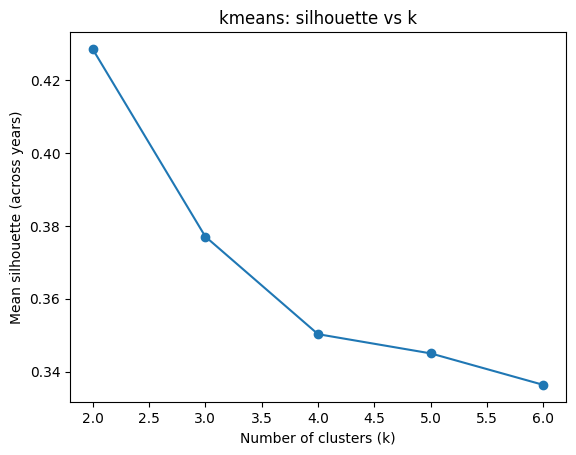

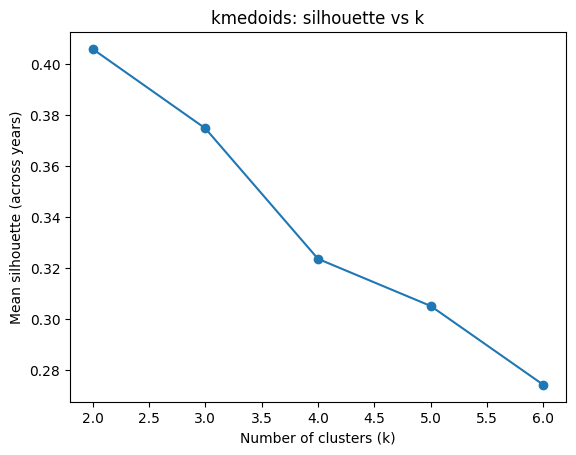

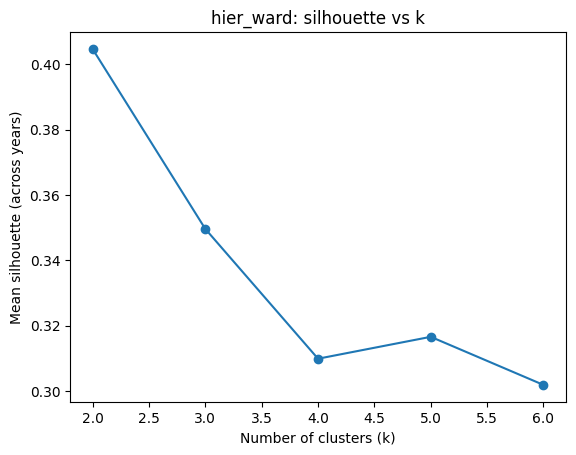

In [128]:
import matplotlib.pyplot as plt

methods_geo = ["kmeans", "kmedoids", "hier_ward"]

for m in methods_geo:
    d = agg_geo[agg_geo["method"] == m].sort_values("k")
    plt.figure()
    plt.plot(d["k"], d["sil_mean"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Mean silhouette (across years)")
    plt.title(f"{m}: silhouette vs k")
    plt.show()

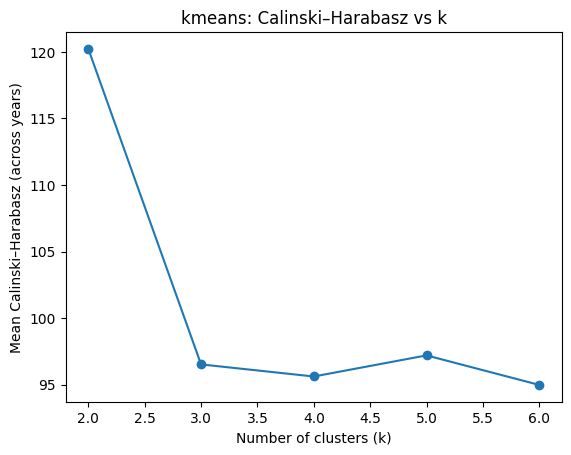

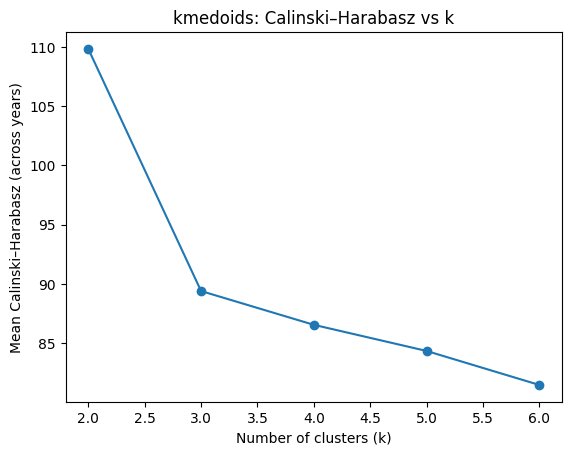

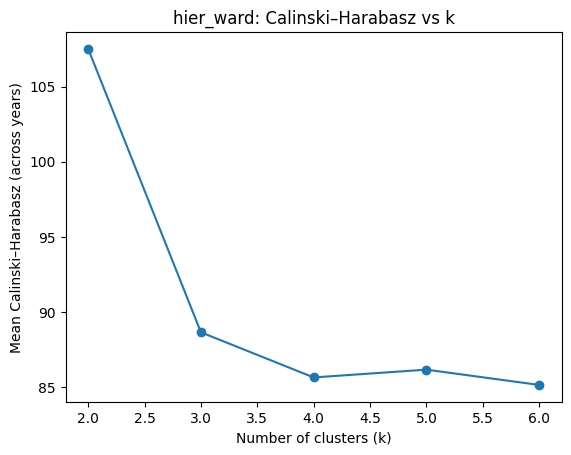

In [129]:
for m in methods_geo:
    d = agg_geo[agg_geo["method"] == m].sort_values("k")
    plt.figure()
    plt.plot(d["k"], d["ch_mean"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Mean Calinski–Harabasz (across years)")
    plt.title(f"{m}: Calinski–Harabasz vs k")
    plt.show()

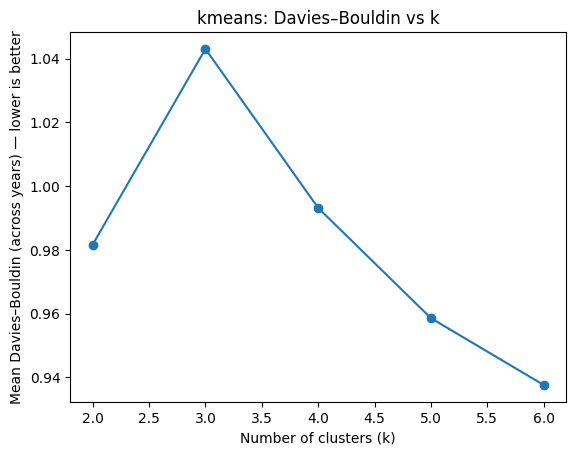

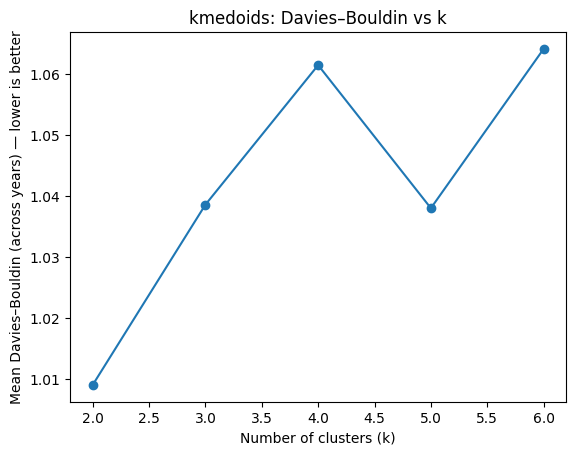

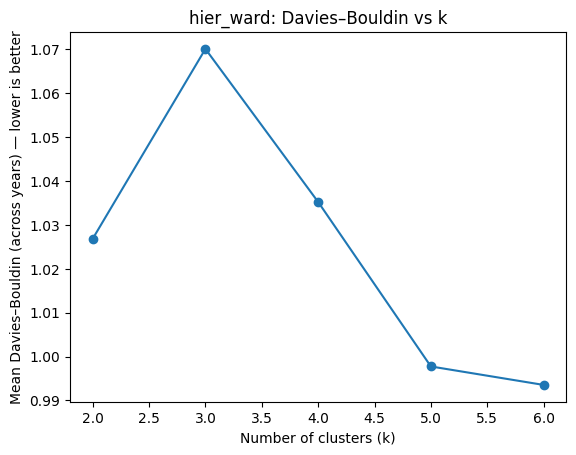

In [130]:
for m in methods_geo:
    d = agg_geo[agg_geo["method"] == m].sort_values("k")
    plt.figure()
    plt.plot(d["k"], d["db_mean"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Mean Davies–Bouldin (across years) — lower is better")
    plt.title(f"{m}: Davies–Bouldin vs k")
    plt.show()

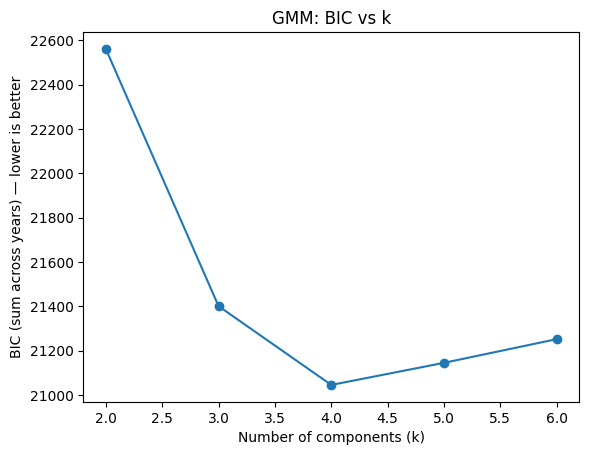

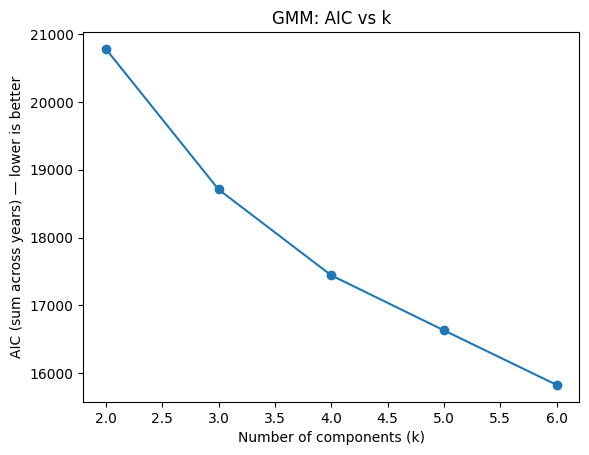

In [131]:
d = agg_gmm.sort_values("k")

plt.figure()
plt.plot(d["k"], d["bic_sum"], marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("BIC (sum across years) — lower is better")
plt.title("GMM: BIC vs k")
plt.show()

plt.figure()
plt.plot(d["k"], d["aic_sum"], marker="o")
plt.xlabel("Number of components (k)")
plt.ylabel("AIC (sum across years) — lower is better")
plt.title("GMM: AIC vs k")
plt.show()

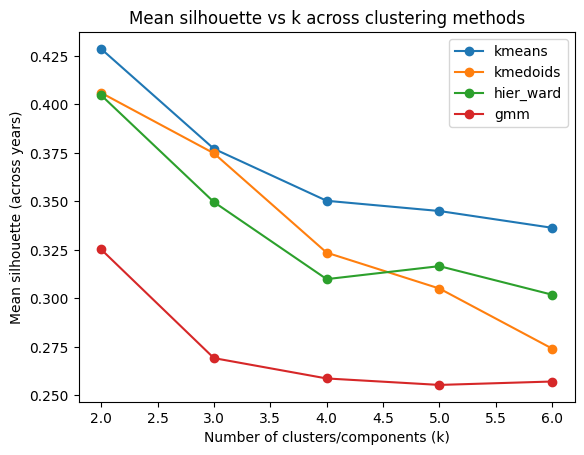

In [ ]:
plt.figure()

for m in methods_geo:
    d = agg_geo[agg_geo["method"] == m].sort_values("k")
    plt.plot(d["k"], d["sil_mean"], marker="o", label=m)


plt.plot(agg_gmm.sort_values("k")["k"], agg_gmm.sort_values("k")["sil_mean"],
         marker="o", label="gmm")

plt.xlabel("Number of clusters/components (k)")
plt.ylabel("Mean silhouette (across years)")
plt.title("Mean silhouette vs k across clustering methods")
plt.legend()
plt.show()

# 2 alternative normalizations (robustness)

A. Pooled standardization (no whole sample)
B. Baseline normalization (eg relative to 2010)

In [ ]:
def run_kmeans_clustering(df, features, k=3, random_state=123, scale=False):

    df = df.copy()

    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(df[features])
    else:
        X = df[features].values   

    km = KMeans(n_clusters=k, n_init=50, random_state=random_state)
    labels = km.fit_predict(X)

    df["cluster_nr_"] = labels + 1

    return df[["country", "year", "cluster_nr_"]], labels

In [134]:
# A. pooled z-score

df_pooled = df_cy.copy()

scaler = StandardScaler()
df_pooled[features] = scaler.fit_transform(df_pooled[features])

In [ ]:
# B. baseline (eg. 2010)

df_base = df_cy.copy()

base = df_base[df_base["year"] == 2010][features]

mu = base.mean()
sigma = base.std()

df_base[features] = (df_base[features] - mu) / sigma

In [ ]:
# Clustering (k-means) on those two versions

df_yearly = df_cy.copy()      # yearly z-score
df_pooled = df_pooled.copy()  # pooled
df_base   = df_base.copy()    # baseline 2010

features = ["ftri_overall", "semicond_share", "hittech_exp", "serv_va_pop", "reg_ict"]

cluster_yearly, labels_yearly = run_kmeans_clustering(df_yearly, features)
cluster_pooled, labels_pooled = run_kmeans_clustering(df_pooled, features)
cluster_base,   labels_base   = run_kmeans_clustering(df_base, features)

In [146]:
df_compare = (
    cluster_yearly
    .rename(columns={"cluster_nr_": "cluster_yearly"})
    .merge(cluster_pooled.rename(columns={"cluster_nr_": "cluster_pooled"}),
           on=["country", "year"])
    .merge(cluster_base.rename(columns={"cluster_nr_": "cluster_base"}),
           on=["country", "year"])
)

In [147]:
from sklearn.metrics import adjusted_rand_score

ari_yearly_pooled = adjusted_rand_score(df_compare["cluster_yearly"], df_compare["cluster_pooled"])
ari_yearly_base   = adjusted_rand_score(df_compare["cluster_yearly"], df_compare["cluster_base"])

print("ARI yearly vs pooled:", round(ari_yearly_pooled, 3))
print("ARI yearly vs baseline:", round(ari_yearly_base, 3))

ARI yearly vs pooled: 0.439
ARI yearly vs baseline: 0.451


In [148]:
agreement_pooled = np.mean(df_compare["cluster_yearly"] == df_compare["cluster_pooled"])
agreement_base   = np.mean(df_compare["cluster_yearly"] == df_compare["cluster_base"])

print("Agreement yearly vs pooled:", round(agreement_pooled, 3))
print("Agreement yearly vs baseline:", round(agreement_base, 3))

Agreement yearly vs pooled: 0.057
Agreement yearly vs baseline: 0.056


In [149]:
pd.crosstab(df_compare["cluster_yearly"].shift(), df_compare["cluster_yearly"], normalize="index")
pd.crosstab(df_compare["cluster_pooled"].shift(), df_compare["cluster_pooled"], normalize="index")
pd.crosstab(df_compare["cluster_base"].shift(), df_compare["cluster_base"], normalize="index")

cluster_base,1,2,3
cluster_base,,,
1.0,0.966837,0.026786,0.006378
2.0,0.068471,0.921975,0.009554
3.0,0.090909,0.070707,0.838384


In [150]:
robustness_table = pd.DataFrame({
    "comparison": ["yearly vs pooled", "yearly vs baseline"],
    "ARI": [ari_yearly_pooled, ari_yearly_base],
    "Agreement": [agreement_pooled, agreement_base]
})

robustness_table

,comparison,ARI,Agreement
0,yearly vs pooled,0.438832,0.057491
1,yearly vs baseline,0.450844,0.055749


In [ ]:
from scipy.optimize import linear_sum_assignment

def relabel_to_match(ref_labels, other_labels):
    """
    Mapuje etykiety other -> ref (dla 1..K), maksymalizując zgodność.
    Zwraca przemianowane other_labels.
    """
    ref = np.asarray(ref_labels)
    oth = np.asarray(other_labels)

    ref_u = np.sort(np.unique(ref))
    oth_u = np.sort(np.unique(oth))
    K = max(len(ref_u), len(oth_u))

    # contingency
    ct = pd.crosstab(ref, oth).reindex(index=ref_u, columns=oth_u, fill_value=0).values

    row_ind, col_ind = linear_sum_assignment(-ct)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        if r < len(ref_u) and c < len(oth_u):
            mapping[oth_u[c]] = ref_u[r]

    # apply mapping 
    relabeled = np.array([mapping.get(x, x) for x in oth])
    return relabeled, mapping


pooled_rel, map_pooled = relabel_to_match(df_compare["cluster_yearly"], df_compare["cluster_pooled"])
base_rel,   map_base   = relabel_to_match(df_compare["cluster_yearly"], df_compare["cluster_base"])

agreement_pooled_mapped = np.mean(df_compare["cluster_yearly"].values == pooled_rel)
agreement_base_mapped   = np.mean(df_compare["cluster_yearly"].values == base_rel)

print("Mapped agreement yearly vs pooled:", round(agreement_pooled_mapped, 3), "mapping:", map_pooled)
print("Mapped agreement yearly vs baseline:", round(agreement_base_mapped, 3), "mapping:", map_base)

Mapped agreement yearly vs pooled: 0.809 mapping: {2: 1, 3: 2, 1: 3}
Mapped agreement yearly vs baseline: 0.814 mapping: {2: 1, 3: 2, 1: 3}


In [153]:
from sklearn.metrics import adjusted_rand_score

ari_yearly_pooled = adjusted_rand_score(df_compare["cluster_yearly"], df_compare["cluster_pooled"])
ari_yearly_base   = adjusted_rand_score(df_compare["cluster_yearly"], df_compare["cluster_base"])

robustness_table = pd.DataFrame({
    "comparison": ["yearly vs pooled", "yearly vs baseline"],
    "ARI (label-invariant)": [ari_yearly_pooled, ari_yearly_base],
    "Agreement (after relabeling)": [agreement_pooled_mapped, agreement_base_mapped],
})

robustness_table

,comparison,ARI (label-invariant),Agreement (after relabeling)
0,yearly vs pooled,0.438832,0.809233
1,yearly vs baseline,0.450844,0.813589


In [154]:
raw_agreement = np.mean(df_compare["cluster_yearly"] == df_compare["cluster_pooled"])
mapped_agreement = np.mean(df_compare["cluster_yearly"].values == pooled_rel)

print(raw_agreement, mapped_agreement)

0.05749128919860627 0.8092334494773519


# Additional stats for modelling

In [24]:
# Non-imputed database
master = pd.read_pickle(main_dir+"df_cluster_kmeans.pickle")

In [17]:
# New stats
data = pd.read_csv(main_dir+"additional_stats.csv")

broad = data[data['Series Name'] == 'Fixed broadband subscriptions']
serv = data[data['Series Name'] == 'Secure Internet servers']
intusr = data[data['Series Name'] == 'Individuals using the Internet (% of population)']

broad = broad.rename(columns={"Country Name":"country","Time":"year","Value":"broadband"}).drop(columns=["Series Name"])
broad = broad.dropna(subset=["country"])
broad["year"] = broad["year"].astype(int)

serv = serv.rename(columns={"Country Name":"country","Time":"year","Value":"servers"}).drop(columns=["Series Name"])
serv = serv.dropna(subset=["country"])
serv["year"] = serv["year"].astype(int)

intusr = intusr.rename(columns={"Country Name":"country","Time":"year","Value":"int_users"}).drop(columns=["Series Name"])
intusr = intusr.dropna(subset=["country"])
intusr["year"] = intusr["year"].astype(int)

pop["year"] = pop["year"].astype(int)

In [26]:
mapping, unmatched_df2, unmatched_df1 = fuzzy_country_match(master['country'], broad['country'], verbose=True)

Not matched from df2:
- Turkmenistan
- French Polynesia
- West Bank and Gaza
- Somalia, Fed. Rep.
- Equatorial Guinea
- Channel Islands
- Monaco
- Puerto Rico (US)
- Turks and Caicos Islands
- Faroe Islands
- Gibraltar
- Curacao
- New Caledonia
- Sint Maarten (Dutch part)
- Iraq
- Vanuatu
- Venezuela, RB
- Dominica
- Macao SAR, China
- Tuvalu
- Guam
- St. Kitts and Nevis
- Korea, Dem. People's Rep.
- San Marino
- Cayman Islands
- British Virgin Islands
- Eritrea
- Haiti
- Syrian Arab Republic
- Grenada
- South Sudan
- Ethiopia
- Palau
- Seychelles
- Bermuda
- Kiribati
- Liechtenstein
- Northern Mariana Islands
- Nauru
- Andorra
- St. Martin (French part)
- Serbia
- Chad
- Micronesia, Fed. Sts.
- Marshall Islands
- Kosovo
- American Samoa
- Virgin Islands (U.S.)
- Antigua and Barbuda
- Greenland
- Isle of Man
- Aruba
- Tonga

Names from df1 without match in df2:

Mapping dict df2 → df1:
{'Sierra Leone': 'Sierra Leone', 'Brunei Darussalam': 'Brunei Darussalam', 'Jordan': 'Jordan', 'Benin

In [29]:
from functools import reduce

dfs = [broad, serv, intusr, pop]

master_upd = master.copy()

master_upd = reduce(
    lambda left, right: left.merge(right, on=['country','year'], how='left'),
    dfs,
    master
)

In [31]:
master_upd['broad_pop'] = master_upd['broadband'] / master_upd['pop']
master_upd['servers_pop'] = master_upd['servers'] / master_upd['pop']

In [35]:
master_upd.to_pickle(main_dir+"df_cluster_stata.pickle")
master_upd.to_csv(main_dir+"df_cluster_stata.csv")

In [23]:
master_upd = pd.read_pickle(main_dir+"df_cluster_stata.pickle")